In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

df = pd.read_csv("/content/Tempering data for carbon and low alloy steels - Raiipa.csv")

In [69]:
df.head(3) #raw data

,Source,Steel type,Initial hardness (HRC) - post quenching,Tempering time (s),Tempering temperature (ºC),C (%wt),Mn (%wt),P (%wt),S (%wt),Si (%wt),Ni (%wt),Cr (%wt),Mo (%wt),V (%wt),Al (%wt),Cu (%wt),Final hardness (HRC) - post tempering
0,"Grange and Baughman, 1956",AISI-SAE 1026,?,600,204.4,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,50.6
1,"Grange and Baughman, 1956",AISI-SAE 1026,?,600,260.0,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,48.3
2,"Grange and Baughman, 1956",AISI-SAE 1026,?,600,315.6,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,43.7


In [70]:
df = df.drop(["Source", "Steel type", "Initial hardness (HRC) - post quenching"], axis = "columns")

In [71]:
df.head(3)

,Tempering time (s),Tempering temperature (ºC),C (%wt),Mn (%wt),P (%wt),S (%wt),Si (%wt),Ni (%wt),Cr (%wt),Mo (%wt),V (%wt),Al (%wt),Cu (%wt),Final hardness (HRC) - post tempering
0,600,204.4,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,50.6
1,600,260.0,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,48.3
2,600,315.6,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,43.7


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1466 entries, 0 to 1465
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tempering time (s)                     1466 non-null   int64  
 1   Tempering temperature (ºC)             1466 non-null   float64
 2   C (%wt)                                1466 non-null   float64
 3   Mn (%wt)                               1466 non-null   float64
 4   P (%wt)                                1466 non-null   float64
 5   S (%wt)                                1466 non-null   float64
 6   Si (%wt)                               1466 non-null   float64
 7   Ni (%wt)                               1466 non-null   float64
 8   Cr (%wt)                               1466 non-null   float64
 9   Mo (%wt)                               1466 non-null   float64
 10  V (%wt)                                1466 non-null   float64
 11  Al (

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [88]:
x = df.drop(['Final hardness (HRC) - post tempering'], axis = "columns")
y = df["Final hardness (HRC) - post tempering"]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state = 42, test_size = 0.2)

In [74]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(xtrain, ytrain)

LinearRegression()

In [75]:
lr.score(xtest, ytest)

0.8909243893644265

With Scaling

In [76]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)
xtrain_scaled

array([[-2.35364701e-01, -6.16876850e-01, -9.00718140e-01, ...,
        -1.81369063e-01, -1.70370823e-01, -3.18608855e-01],
       [-5.47625786e-01, -3.02314215e-01, -9.00718140e-01, ...,
        -1.81369063e-01, -1.70370823e-01, -3.18608855e-01],
       [-5.47625786e-01,  3.27377835e-01,  6.29458446e-01, ...,
        -1.81369063e-01, -1.70370823e-01, -3.18608855e-01],
       ...,
       [-5.47625786e-01,  1.58676193e+00, -4.50666203e-01, ...,
        -1.81369063e-01,  5.86954963e+00, -3.18608855e-01],
       [-5.47625786e-01,  1.58676193e+00,  7.64474027e-01, ...,
        -1.81369063e-01, -1.70370823e-01, -3.18608855e-01],
       [-3.91495244e-01,  1.56182363e+00, -6.14265610e-04, ...,
        -1.81369063e-01, -1.70370823e-01, -3.18608855e-01]])

<Axes: >

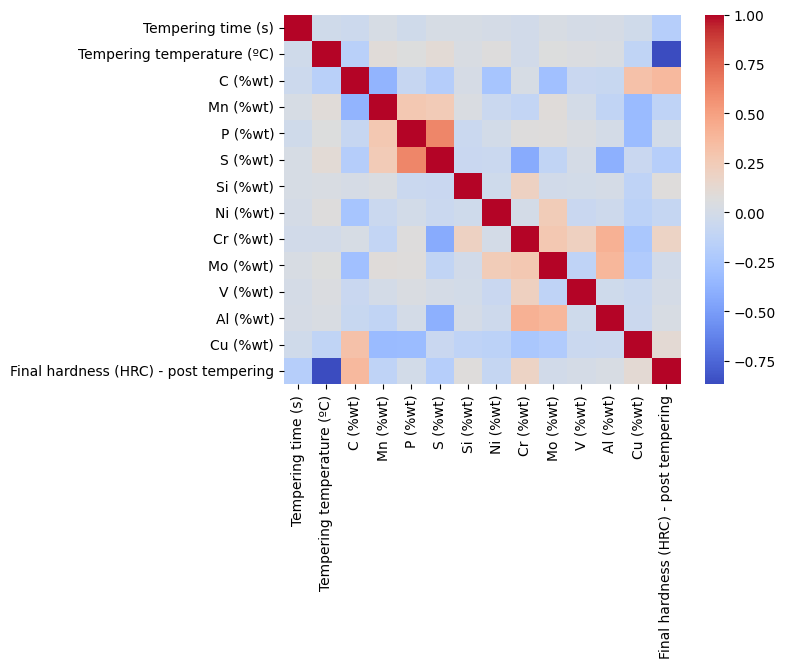

In [77]:
import seaborn as sns
sns.heatmap(df.corr(), cmap = 'coolwarm')

Checking RandomForest, SVR and LinearRegression With Pipeline Scaling

In [78]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth = 10) #max depth was kept as 10 to prevent overfitting.

rfr.fit(xtrain,ytrain)


RandomForestRegressor(max_depth=10)

In [79]:
rfr.score(xtest,ytest)

0.9777003983888768

In [87]:
score_rfr = cross_val_score(rfr, x, y, cv = 5)
print("Cross-Val Score Of Random Forest=", score_rfr.mean())

Cross-Val Score Of Random Forest= 0.8995467918116965


Pipe Line For SVR With Scaling

In [81]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])

scores = cross_val_score(pipe, x, y, cv = 5)
print("Cross Val Score Of SVR is",scores.mean())

Cross Val Score Of SVR is 0.6515621846383186


Piple Line For LR With Scaling

In [82]:
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

scores = cross_val_score(pipe2, x, y, cv = 5)
print("Cross Val Score Of LR is",scores.mean())

Cross Val Score Of LR is 0.8059789818791703


Analysis Of Model

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = rfr.predict(xtest)

print("MAE:", mean_absolute_error(ytest, pred))
print("RMSE:", np.sqrt(mean_squared_error(ytest, pred)))

MAE: 0.9241803473528378
RMSE: 1.4182548903166903


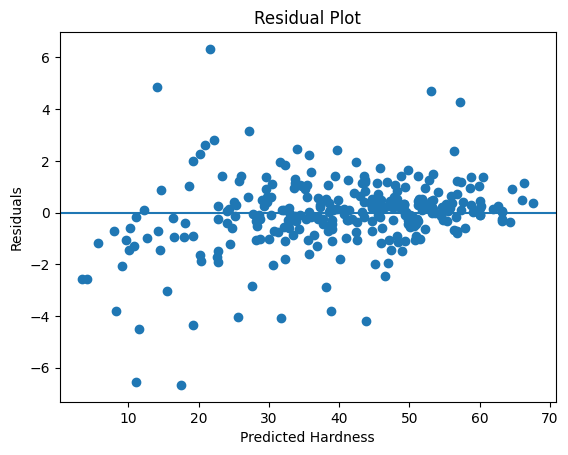

In [95]:
residuals = ytest - pred

plt.scatter(pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Hardness")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [96]:
pip install shap

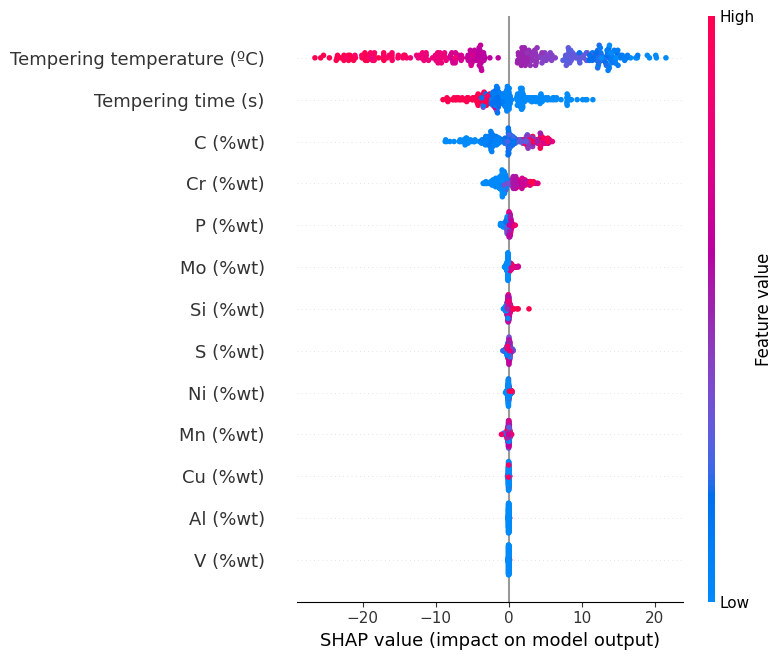

In [98]:
import shap

explainer = shap.TreeExplainer(rfr)

shap.summary_plot(explainer.shap_values(xtest), xtest)